In [2]:
import pandas as pd

## Analysis on Transactions

In [3]:
transaction_df = pd.read_excel('QVI_transaction_data.xlsx')

transaction_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [5]:
transaction_df.shape

(264836, 8)

In [6]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [9]:
transaction_df.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [10]:
duplicates = transaction_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 1


In [20]:
transaction_df = transaction_df.drop_duplicates()

print(f"Shape after removing duplicates : {transaction_df.shape}")

Shape after removing duplicates : (264835, 8)


In [ ]:
negative_qty = (transaction_df['PROD_QTY'] <= 0).sum()
negative_sales = (transaction_df['TOT_SALES'] <= 0).sum()
print(f"Negative or zero PROD_QTY: {negative_qty}")
print(f"Negative or zero TOT_SALES: {negative_sales}")

Negative or zero PROD_QTY: 0
Negative or zero TOT_SALES: 0


In [12]:
transaction_df[['PROD_QTY', 'TOT_SALES']].describe()

,PROD_QTY,TOT_SALES
count,264836.000000,264836.000000
mean,1.907309,7.304200
std,0.643654,3.083226
min,1.000000,1.500000
25%,2.000000,5.400000
50%,2.000000,7.400000
75%,2.000000,9.200000
max,200.000000,650.000000


In [22]:
# Calculate Q1, Q3, and IQR for PROD_QTY
Q1_qty = transaction_df['PROD_QTY'].quantile(0.25)
Q3_qty = transaction_df['PROD_QTY'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
lower_bound_qty = Q1_qty - 1.5 * IQR_qty
upper_bound_qty = Q3_qty + 1.5 * IQR_qty

# Calculate for TOT_SALES
Q1_sales = transaction_df['TOT_SALES'].quantile(0.25)
Q3_sales = transaction_df['TOT_SALES'].quantile(0.75)
IQR_sales = Q3_sales - Q1_sales
lower_bound_sales = Q1_sales - 1.5 * IQR_sales
upper_bound_sales = Q3_sales + 1.5 * IQR_sales

#Count Outliers before flitering
outliers_qty = ((transaction_df['PROD_QTY'] < lower_bound_qty) | (transaction_df['PROD_QTY'] > upper_bound_qty)).sum()
outliers_sales = ((transaction_df['TOT_SALES'] < lower_bound_sales) | (transaction_df['TOT_SALES'] > upper_bound_sales)).sum()
print(f"Outliers in PROD_QTY: {outliers_qty}")
print(f"Outliers in TOT_SALES: {outliers_sales}")

# Filter out outliers
transaction_df = transaction_df[
    (transaction_df['PROD_QTY'] >= lower_bound_qty) & (transaction_df['PROD_QTY'] <= upper_bound_qty) &
    (transaction_df['TOT_SALES'] >= lower_bound_sales) & (transaction_df['TOT_SALES'] <= upper_bound_sales)
]
print(f"Shape after removing outliers: {transaction_df.shape}")

Outliers in PROD_QTY: 0
Outliers in TOT_SALES: 0
Shape after removing outliers: (236038, 8)


In [24]:
# Convert DATE to datetime (only if not already converted)
if transaction_df['DATE'].dtype != 'datetime64[ns]':
    transaction_df['DATE'] = pd.to_datetime(transaction_df['DATE'], origin='1899-12-30', unit='D', errors='coerce')

# Check for invalid dates (NaT values)
invalid_dates = transaction_df['DATE'].isna().sum()
print(f"Invalid dates after conversion: {invalid_dates}")

# If many are invalid, inspect the original values
print(transaction_df['DATE'].head())  # Check converted dates
print(transaction_df['DATE'].min(), transaction_df['DATE'].max())  # Check date range

Invalid dates after conversion: 0
0    2018-10-17
2    2019-05-20
9    2018-08-18
12   2019-05-18
24   2018-08-15
Name: DATE, dtype: datetime64[ns]
2018-07-01 00:00:00 2019-06-30 00:00:00


In [26]:
transaction_df['DATE'].head(10)

0    2018-10-17
2    2019-05-20
9    2018-08-18
12   2019-05-18
24   2018-08-15
26   2018-08-19
32   2019-05-20
38   2018-08-18
53   2019-05-19
57   2019-05-14
Name: DATE, dtype: datetime64[ns]

Unique product names: 114


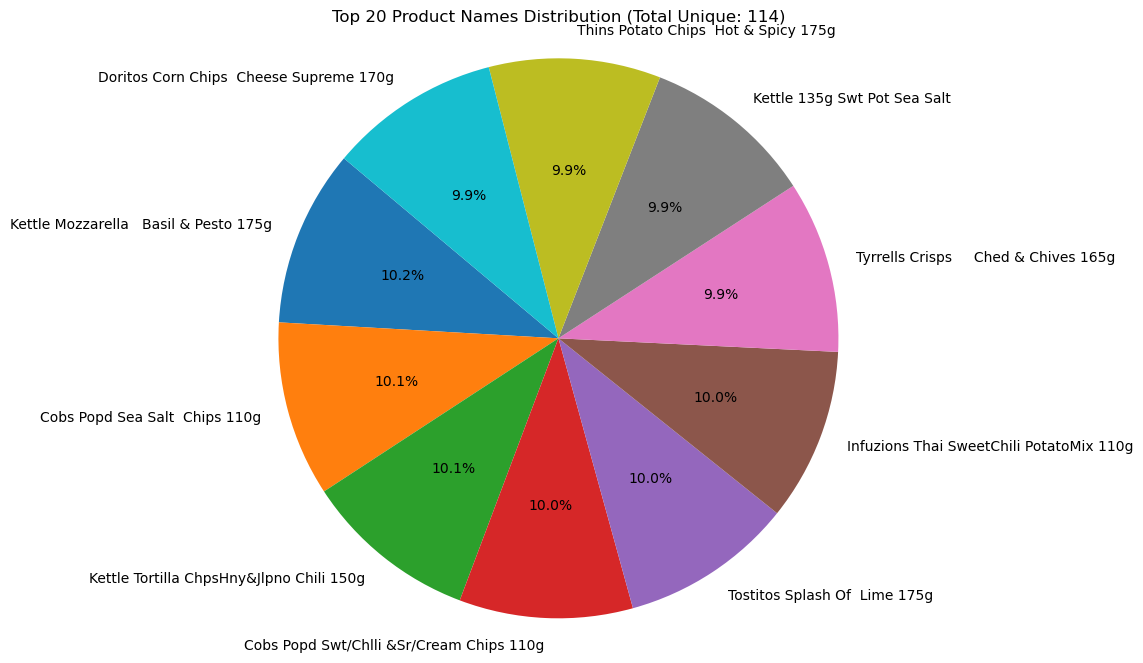

In [30]:
import matplotlib.pyplot as plt
unique_prod_names = transaction_df['PROD_NAME'].nunique()
print(f"Unique product names: {unique_prod_names}")
# Inspect a sample for irregularities
top_20_prod = transaction_df['PROD_NAME'].value_counts().head(10)

#Create a pie chart for this visualization
plt.figure(figsize=(10,8))
plt.pie(top_20_prod.values, labels=top_20_prod.index, autopct='%1.1f%%', startangle=140)
plt.title(f'Top 20 Product Names Distribution (Total Unique: {unique_prod_names})')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()
